In [1]:
# Upload training and testing datasets
from google.colab import files
uploaded = files.upload()

Saving train_KNN (1).csv to train_KNN (1).csv
Saving test_KNN (1).csv to test_KNN (1).csv


In [2]:
# Import necessary libraries for data handling, visualization, and ML models
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Evaluation
from sklearn.metrics import accuracy_score

In [4]:
# Load the training and testing datasets
df_train = pd.read_csv("train_KNN (1).csv")
df_test = pd.read_csv("test_KNN (1).csv")

# Display dataset structure
df_train.info()
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived

In [5]:
# Check missing values in training data
print(df_train.isnull().sum())

# Calculate percentage of missing values
mp = 100 * (df_train.isnull().sum() / len(df_train))
mp = mp[mp > 0].sort_values()

print(mp)

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
Embarked     0.224467
Age         19.865320
Cabin       77.104377
dtype: float64


In [6]:
# Remove rows where 'Embarked' is missing
df_train = df_train.dropna(subset=["Embarked"])

# Fill missing Age values with median
df_train["Age"] = df_train["Age"].fillna(df_train["Age"].median())

# Drop 'Cabin' column due to too many missing values
df_train = df_train.drop(["Cabin"], axis=1)

In [7]:
# Check missing values in test data
mpt = 100 * (df_test.isnull().sum() / len(df_test))
mpt = mpt[mpt > 0].sort_values()
print(mpt)

# Remove rows where Fare is missing
df_test = df_test.dropna(subset=["Fare"])

# Fill missing Age values
df_test["Age"] = df_test["Age"].fillna(df_test["Age"].median())

# Drop 'Cabin' column
df_test = df_test.drop(["Cabin"], axis=1)

Fare      0.239234
Age      20.574163
Cabin    78.229665
dtype: float64


In [8]:
# Remove irrelevant columns that do not contribute to prediction
df_train.drop(["PassengerId", "Name", "Ticket"], axis=1, inplace=True)
df_test.drop(["PassengerId", "Name", "Ticket"], axis=1, inplace=True)

In [9]:
# Convert categorical columns to string type for encoding
df_train["Survived"] = df_train["Survived"].astype(str)
df_train["Pclass"] = df_train["Pclass"].astype(str)

df_test["Survived"] = df_test["Survived"].astype(str)
df_test["Pclass"] = df_test["Pclass"].astype(str)

In [10]:
# Split dataset into numeric and categorical parts
df_train_num = df_train.select_dtypes(exclude="object")
df_train_obj = df_train.select_dtypes(include="object")

df_test_num = df_test.select_dtypes(exclude="object")
df_test_obj = df_test.select_dtypes(include="object")

In [11]:
# Convert categorical variables into dummy/indicator variables
df_train_obj = pd.get_dummies(df_train_obj, drop_first=True)
df_test_obj = pd.get_dummies(df_test_obj, drop_first=True)

In [12]:
# Ensure both train and test datasets have same columns after encoding
df_train_obj, df_test_obj = df_train_obj.align(df_test_obj, join='left', axis=1, fill_value=0)

In [13]:
# Merge numeric and encoded categorical features
Final_train_df = pd.concat([df_train_num, df_train_obj], axis=1)
Final_test_df = pd.concat([df_test_num, df_test_obj], axis=1)

Final_train_df.head()

,Age,SibSp,Parch,Fare,Survived_1,Pclass_2,Pclass_3,Sex_male,Embarked_Q,Embarked_S
0,22.0,1,0,7.2500,False,False,True,True,False,True
1,38.0,1,0,71.2833,True,False,False,False,False,False
2,26.0,0,0,7.9250,True,False,True,False,False,True
3,35.0,1,0,53.1000,True,False,False,False,False,True
4,35.0,0,0,8.0500,False,False,True,True,False,True


In [19]:
X_train = Final_train_df.drop("Survived_1", axis=1)
y_train = Final_train_df["Survived_1"].astype(int)

X_test = Final_test_df.drop("Survived_1", axis=1)
y_test = Final_test_df["Survived_1"].astype(int)

In [20]:
# Standardize the feature values (important for KNN & Logistic Regression)
scaler = StandardScaler()

scaled_X_train = scaler.fit_transform(X_train)
scaled_X_test = scaler.transform(X_test)

In [21]:
# Initialize KNN model with k=5
knn = KNeighborsClassifier(n_neighbors=5)

# Train the model
knn.fit(scaled_X_train, y_train)

# Predict on test data
y_pred_knn = knn.predict(scaled_X_test)

# Evaluate accuracy
acc_knn = accuracy_score(y_test, y_pred_knn)
print("KNN Accuracy:", acc_knn)

KNN Accuracy: 0.8129496402877698


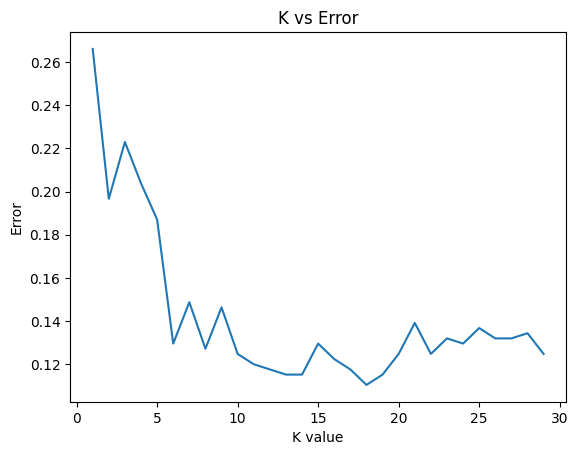

In [22]:
# Analyze error rate for different values of K
error = []

for k in range(1, 30):
    knn_k = KNeighborsClassifier(n_neighbors=k)
    knn_k.fit(scaled_X_train, y_train)
    pred_k = knn_k.predict(scaled_X_test)
    error.append(1 - accuracy_score(y_test, pred_k))

# Plot graph
plt.plot(range(1,30), error)
plt.xlabel("K value")
plt.ylabel("Error")
plt.title("K vs Error")
plt.show()

In [23]:
# Initialize Logistic Regression model
lr = LogisticRegression(max_iter=1000)

# Train model
lr.fit(scaled_X_train, y_train)

# Predict
y_pred_lr = lr.predict(scaled_X_test)

# Accuracy
acc_lr = accuracy_score(y_test, y_pred_lr)
print("Logistic Regression Accuracy:", acc_lr)

Logistic Regression Accuracy: 0.947242206235012


In [24]:
# Initialize Decision Tree model
dt = DecisionTreeClassifier(random_state=42)

# Train model (no scaling needed)
dt.fit(X_train, y_train)

# Predict
y_pred_dt = dt.predict(X_test)

# Accuracy
acc_dt = accuracy_score(y_test, y_pred_dt)
print("Decision Tree Accuracy:", acc_dt)

Decision Tree Accuracy: 0.7721822541966427


In [25]:
# Compare all models
print("\n=== FINAL MODEL COMPARISON ===")
print("KNN:", acc_knn)
print("Logistic Regression:", acc_lr)
print("Decision Tree:", acc_dt)


=== FINAL MODEL COMPARISON ===
KNN: 0.8129496402877698
Logistic Regression: 0.947242206235012
Decision Tree: 0.7721822541966427


SUMMARY RESULT


In [26]:
# ===============================
# FINAL RESULTS SUMMARY
# ===============================

from sklearn.metrics import confusion_matrix

print("\n========== FINAL MODEL RESULTS ==========\n")

# Accuracy comparison
print("Accuracy Scores:")
print(f"KNN: {acc_knn:.4f}")
print(f"Logistic Regression: {acc_lr:.4f}")
print(f"Decision Tree: {acc_dt:.4f}")

# Confusion Matrices
print("\nConfusion Matrix - KNN")
print(confusion_matrix(y_test, y_pred_knn))

print("\nConfusion Matrix - Logistic Regression")
print(confusion_matrix(y_test, y_pred_lr))

print("\nConfusion Matrix - Decision Tree")
print(confusion_matrix(y_test, y_pred_dt))


# Best model selection
models = {
    "KNN": acc_knn,
    "Logistic Regression": acc_lr,
    "Decision Tree": acc_dt
}

best_model = max(models, key=models.get)

print("\nBest Performing Model:", best_model)


# Basic interpretation
print("\n=== INTERPRETATION ===")
print("- KNN uses distance-based learning.")
print("- Logistic Regression is linear and more interpretable.")
print("- Decision Tree captures non-linear patterns but may overfit.")

print("\nNOTE:")
print("Very high accuracy may indicate overfitting or data leakage.")


========== FINAL MODEL RESULTS ==========

Accuracy Scores:
KNN: 0.8129
Logistic Regression: 0.9472
Decision Tree: 0.7722

Confusion Matrix - KNN
[[212  53]
 [ 25 127]]

Confusion Matrix - Logistic Regression
[[253  12]
 [ 10 142]]

Confusion Matrix - Decision Tree
[[205  60]
 [ 35 117]]

Best Performing Model: Logistic Regression

=== INTERPRETATION ===
- KNN uses distance-based learning.
- Logistic Regression is linear and more interpretable.
- Decision Tree captures non-linear patterns but may overfit.

NOTE:
Very high accuracy may indicate overfitting or data leakage.
